## K-Means Clustering with Euclidean Distance

Project goal: Build a beginner-friendly doubt-routing system that takes a student's already-preprocessed doubt, groups doubts using K-Means clustering, and recommends the most likely college domain and related topics.


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, confusion_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import pairwise_distances

import warnings
warnings.filterwarnings("ignore")




In [29]:
data = pd.read_csv("Data/cleaned_query_domain_dataset.csv")

data.shape


(6600, 3)

In [51]:
data.head()

,query,label,topic,cluster
0,common mistakes transactional email service s...,Backend,transactional email service,2
1,check confused abbout lightgbm,ML/AI,LightGBM,1
2,«rem vs em units interview questions asap»,Frontend,rem vs em units,1
3,confused web accessibility,Frontend,web accessibility,1
4,iso nbsp 27001 step step guide,Cyber Security,ISO 27001,5


In [30]:
data.shape

(6600, 3)

In [31]:
data.columns.to_list()

['query', 'label', 'topic']

## Basic Dataset Inspection

Because the dataset is already text-preprocessed, we only verify its structure. We do not perform additional NLP cleaning.


In [32]:
print("Missing values:")
print(data.isnull().sum())

print("\nNumber of unique domains:", data["label"].nunique())
print("Number of unique topics:", data["topic"].nunique())

print("\nDomain distribution:")
display(data["label"].value_counts().to_frame("count"))

print("\nDuplicate rows:", data.duplicated().sum())


Missing values:
query    0
label    0
topic    0
dtype: int64

Number of unique domains: 6
Number of unique topics: 704

Domain distribution:


,count
label,
Backend,1100
ML/AI,1100
Frontend,1100
Cyber Security,1100
Programming Language,1100
DSA,1100



Duplicate rows: 0


## Understand the Six Domains

The dataset contains six broad domains. Their balanced distribution is useful for this educational clustering project.


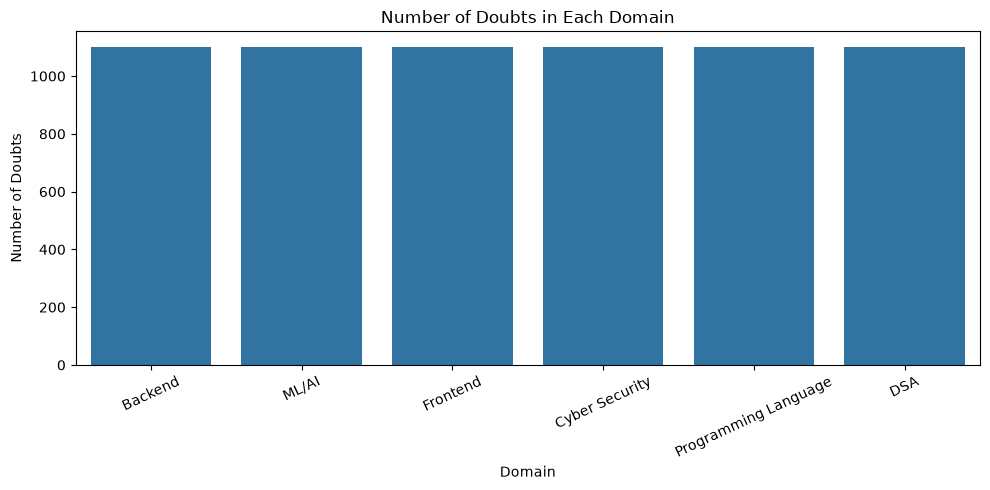

In [33]:
plt.figure(figsize=(10, 5))
sns.countplot(data=data, x="label", order=data["label"].value_counts().index)
plt.title("Number of Doubts in Each Domain")
plt.xlabel("Domain")
plt.ylabel("Number of Doubts")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


## Convert Doubts into TF-IDF Vectors

Machine-learning algorithms need numerical input. TF-IDF converts each already-cleaned query into a numeric vector.

We are not using TF-IDF to calculate similarity. It is only the feature representation. The clustering and all nearest-point decisions below use Euclidean distance.

min_df=2 ignores words that occur in only one record, which reduces extremely rare features.


In [34]:
queries = data["query"].astype(str)

vectorizer = TfidfVectorizer(
    lowercase=False,   # text is already preprocessed
    min_df=2
)

X = vectorizer.fit_transform(queries)

print("TF-IDF matrix shape:", X.shape)
print("Number of TF-IDF features:", len(vectorizer.get_feature_names_out()))


TF-IDF matrix shape: (6600, 1302)
Number of TF-IDF features: 1302


## Choose a Value of K

There are six known broad domains in the dataset, so K=6 is a natural project choice.

Still, we can inspect several K values:
- Inertia: lower is better, but it normally decreases as K increases.
- Silhouette score: higher is generally better. It measures how well-separated the clusters are.

We are using this as an exploratory step, then train the final educational model with K = 6 so that the six clusters can be interpreted as six broad college domains.


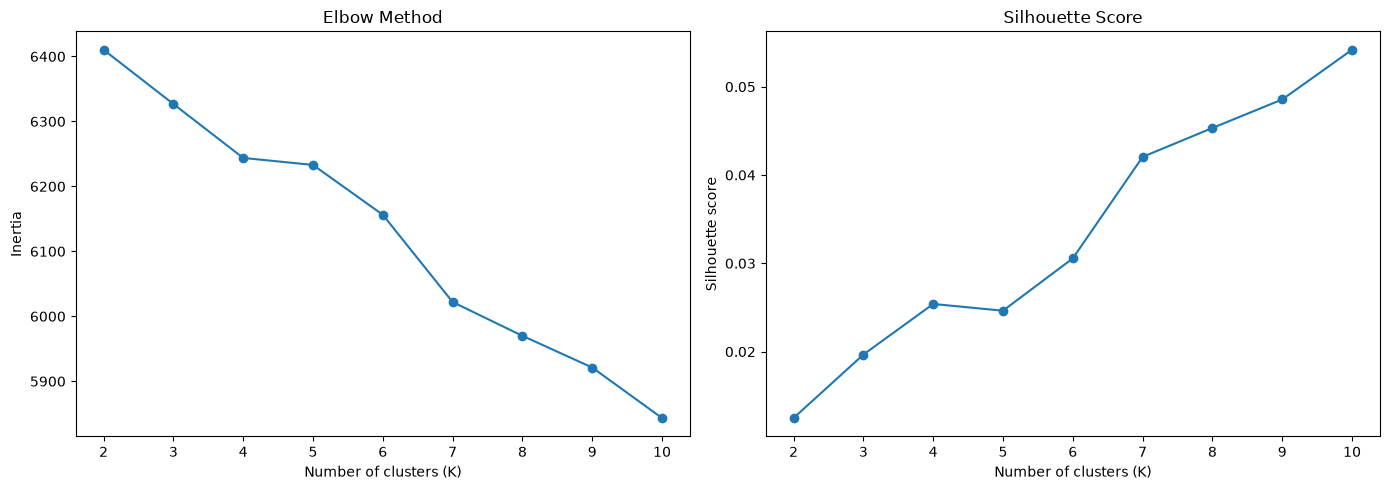

K with the highest silhouette score in this range: 10
Final project K: 6


In [35]:
k_values = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    cluster_ids = model.fit_predict(X)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X, cluster_ids))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_values), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_values), silhouette_scores, marker="o")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

best_silhouette_k = list(k_values)[int(np.argmax(silhouette_scores))]
print("K with the highest silhouette score in this range:", best_silhouette_k)
print("Final project K:", 6)


## Train the Final K-Means Model

K-Means starts with cluster centers and repeatedly:
1. Assigns each doubt to its nearest center.
2. Recalculates the centers.
3. Repeats until the centers stabilize.

The distance used by standard K-Means here is Euclidean distance.

We intentionally keep K=6 because the project is designed to route doubts into the six broad domains present in the dataset.


In [36]:
K = 6

kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

cluster_ids = kmeans.fit_predict(X)

data["cluster"] = cluster_ids

print("K-Means training completed.")
print("Inertia:", round(kmeans.inertia_, 2))
print("\nNumber of records in each cluster:")
print(data["cluster"].value_counts().sort_index())


K-Means training completed.
Inertia: 6156.29

Number of records in each cluster:
cluster
0     290
1    4786
2     307
3     704
4     251
5     262
Name: count, dtype: int64


## What Each Cluster Represents

K-Means gives cluster numbers such as 0, 1, 2, etc. These numbers do not automatically mean Backend, DSA, or Frontend.

For a practical doubt-solving platform, we interpret each cluster using the most common existing domain label inside that cluster.

Again, the labels are not used to train K-Means. They are used only after clustering to give the clusters understandable domain names.


In [37]:
cluster_domain_table = (
    data.groupby("cluster")["label"]
        .agg(
            dominant_domain=lambda s: s.value_counts().index[0],
            domain_count=lambda s: s.value_counts().iloc[0],
            total_doubts="size"
        )
        .reset_index()
)

cluster_domain_table["purity"] = (
    cluster_domain_table["domain_count"] /
    cluster_domain_table["total_doubts"]
)

display(cluster_domain_table.sort_values("cluster"))


,cluster,dominant_domain,domain_count,total_doubts,purity
0,0,Programming Language,57,290,0.196552
1,1,Cyber Security,837,4786,0.174885
2,2,Programming Language,87,307,0.283388
3,3,Cyber Security,129,704,0.183239
4,4,DSA,111,251,0.442231
5,5,Programming Language,47,262,0.179389


## The Domain Distribution Inside Each Cluster

This helps us understand whether each cluster is mostly focused on one domain or mixes several domains.


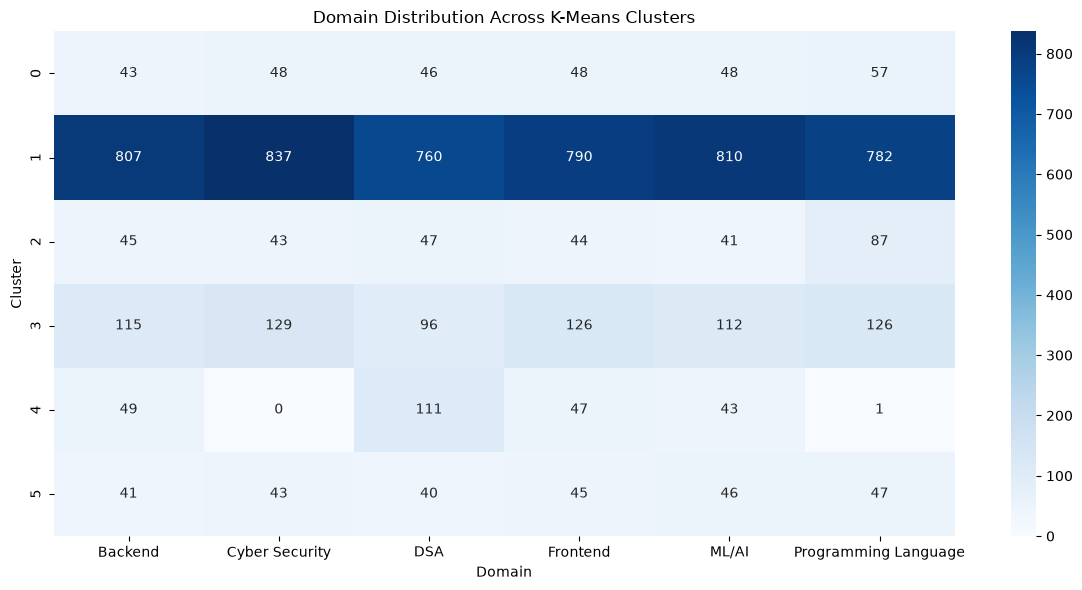

In [38]:
cluster_domain_counts = pd.crosstab(data["cluster"], data["label"])

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_domain_counts, annot=True, fmt="d", cmap="Blues")
plt.title("Domain Distribution Across K-Means Clusters")
plt.xlabel("Domain")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


## Create a 2D Visualization of the Clusters

TF-IDF may contain hundreds or thousands of dimensions. We reduce it to two dimensions using Truncated SVD only for visualization.

This visualization is not used for training or distance calculations.


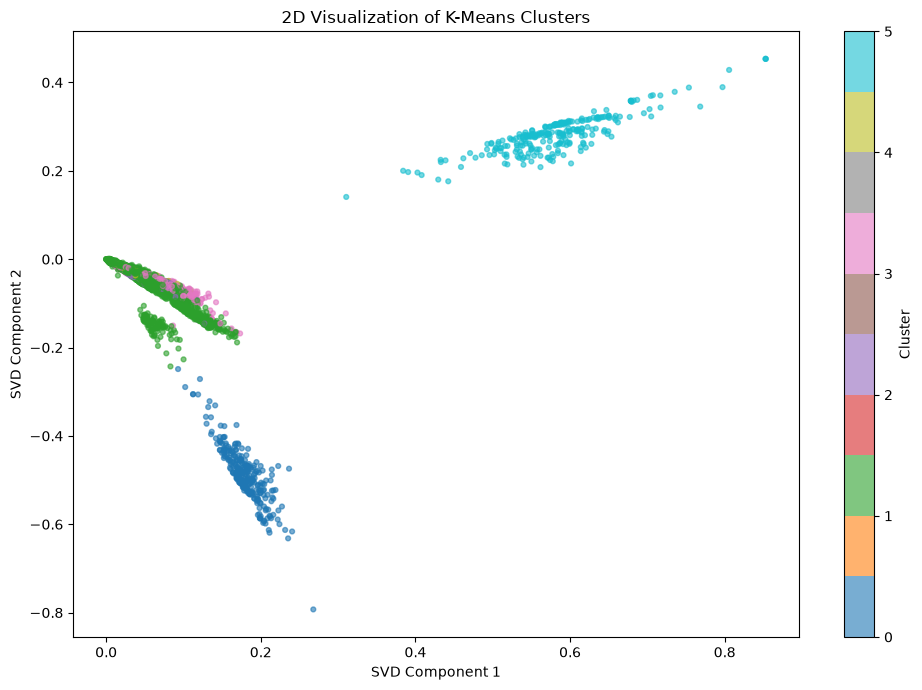

In [40]:
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=data["cluster"],
    s=12,
    alpha=0.6,
    cmap="tab10"
)

plt.title("2D Visualization of K-Means Clusters")
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()


## Explicit Euclidean Distance Function

For a new doubt, we need to determine which K-Means centroid is closest.

Euclidean distance between two vectors x and y is:

distance(x, y) = sqrt(sum((x_i - y_i)^2))

The smallest distance means the vectors are closest in Euclidean space.


In [41]:
def euclidean_distance_to_centroids(vector, centroids):
    """Return Euclidean distance from one vector to every centroid."""
    distances = pairwise_distances(
        vector,
        centroids,
        metric="euclidean"
    )
    return distances[0]


# Verify the calculation for the first dataset query.
first_vector = X[0]
distances = euclidean_distance_to_centroids(first_vector, kmeans.cluster_centers_)

print("Euclidean distance from the first query to each cluster centroid:")
for cluster_id, distance in enumerate(distances):
    print(f"Cluster {cluster_id}: {distance:.4f}")

print("\nNearest cluster:", int(np.argmin(distances)))


Euclidean distance from the first query to each cluster centroid:
Cluster 0: 1.1572
Cluster 1: 1.0011
Cluster 2: 0.9004
Cluster 3: 1.0313
Cluster 4: 1.0446
Cluster 5: 1.1955

Nearest cluster: 2


## Build the Cluster-to-Domain Mapping

The platform needs a readable answer such as:

Recommended domain: ML/AI

instead of:

Cluster 3

So we store the dominant domain of every cluster.


In [42]:
cluster_to_domain = (
    data.groupby("cluster")["label"]
        .agg(lambda s: s.value_counts().index[0])
        .to_dict()
)

cluster_to_domain


{0: 'Programming Language',
 1: 'Cyber Security',
 2: 'Programming Language',
 3: 'Cyber Security',
 4: 'DSA',
 5: 'Programming Language'}

## A Beginner-Friendly Doubt Solver

The function below performs the complete workflow for a new student's doubt:

1. Convert the doubt into the same TF-IDF feature space.
2. Calculate Euclidean distance to every K-Means centroid.
3. Select the nearest centroid.
4. Convert the cluster number into the dominant domain.
5. Find the closest existing doubts inside that cluster using Euclidean distance.
6. Show the topics of those related doubts.

This is a routing/recommendation component. It does not generate an actual answer because the supplied dataset contains queries, domains, and topics, but no answer text.


In [43]:
def solve_doubt(doubt, top_n=5):
    """Route a new doubt to a domain and show related existing doubts."""

    # Convert the new, already-preprocessed doubt to TF-IDF.
    new_vector = vectorizer.transform([doubt])

    # Step 1: Euclidean distance to every K-Means centroid.
    centroid_distances = euclidean_distance_to_centroids(
        new_vector,
        kmeans.cluster_centers_
    )

    nearest_cluster = int(np.argmin(centroid_distances))
    predicted_domain = cluster_to_domain[nearest_cluster]

    # Step 2: Find records inside the selected cluster.
    cluster_mask = data["cluster"].to_numpy() == nearest_cluster
    cluster_indices = np.where(cluster_mask)[0]

    cluster_vectors = X[cluster_indices]

    # Step 3: Euclidean distance from new doubt to existing doubts.
    distances_to_doubts = pairwise_distances(
        new_vector,
        cluster_vectors,
        metric="euclidean"
    )[0]

    nearest_positions = np.argsort(distances_to_doubts)[:top_n]
    nearest_indices = cluster_indices[nearest_positions]

    recommendations = data.iloc[nearest_indices][
        ["query", "label", "topic", "cluster"]
    ].copy()

    recommendations["euclidean_distance"] = distances_to_doubts[nearest_positions]

    return {
        "predicted_domain": predicted_domain,
        "nearest_cluster": nearest_cluster,
        "centroid_distances": centroid_distances,
        "related_doubts": recommendations.reset_index(drop=True)
    }


print("Doubt solver function is ready.")


Doubt solver function is ready.


## Test the Platform with a New Student Doubt

Try replacing the example with your own already-preprocessed doubt.


In [44]:
new_doubt = "how to implement binary search tree traversal"

result = solve_doubt(new_doubt, top_n=5)

print("Student doubt:")
print(new_doubt)

print("\nRecommended domain:")
print(result["predicted_domain"])

print("\nNearest K-Means cluster:")
print(result["nearest_cluster"])

print("\nEuclidean distances to cluster centroids:")
for cluster_id, distance in enumerate(result["centroid_distances"]):
    print(f"Cluster {cluster_id}: {distance:.4f}")

print("\nRelated doubts:")
display(result["related_doubts"])


Student doubt:
how to implement binary search tree traversal

Recommended domain:
DSA

Nearest K-Means cluster:
4

Euclidean distances to cluster centroids:
Cluster 0: 1.1583
Cluster 1: 0.9992
Cluster 2: 1.0840
Cluster 3: 1.0317
Cluster 4: 0.9576
Cluster 5: 1.1953

Related doubts:


,query,label,topic,cluster,euclidean_distance
0,implement binary search c++,DSA,binary search,4,0.843284
1,implement binary search python,DSA,binary search,4,0.916157
2,hello implement binary search java,DSA,binary search,4,0.986665
3,implement balanced binary tree chcek c++,DSA,balanced binary tree check,4,1.025377
4,implement diameter binary tree python,DSA,diameter of binary tree,4,1.041888


## Show the Most Common Topics in the Predicted Domain

The platform can also provide topic-level hints. We find the most common topics within the predicted domain.


In [45]:
predicted_domain = result["predicted_domain"]

common_topics = (
    data[data["label"] == predicted_domain]["topic"]
        .value_counts()
        .head(10)
        .reset_index()
)

common_topics.columns = ["topic", "count"]

print(f"Top topics in the recommended domain: {predicted_domain}")
display(common_topics)


Top topics in the recommended domain: DSA


,topic,count
0,handwritten,15
1,binary search,15
2,serialize and deserialize a tree,15
3,level order traversal,14
4,longest increasing subsequence,14
5,topological sort,14
6,recursion,13
7,dequeue,13
8,Rabin Karp,13
9,N-Queens backtracking,13


## View Example Doubts from Every Cluster

This makes the clustering easier to understand as a beginner.


In [50]:
for cluster_id in sorted(data["cluster"].unique()):
    cluster_rows = data[data["cluster"] == cluster_id]
    domain = cluster_to_domain[cluster_id]

    print("=" * 70)
    print(f"Cluster {cluster_id}  ->  {domain}")
    print("=" * 70)

    display(
        cluster_rows[["query", "label", "topic"]]
        .head(5)
        .reset_index(drop=True)
    )


Cluster 0  ->  Programming Language


,query,label,topic
0,real world use cases full text search,Backend,full text search
1,real world use cases horizontal scaling source,Backend,horizontal scaling
2,real world use cases selection sort,DSA,selection sort
3,real world use cases prefix sum,DSA,prefix sum
4,hi nbsp real world use cases session management,Backend,session management


Cluster 1  ->  Cyber Security


,query,label,topic
0,check confused abbout lightgbm,ML/AI,LightGBM
1,«rem vs em units interview questions asap»,Frontend,rem vs em units
2,confused web accessibility,Frontend,web accessibility
3,nbsp notes ruby symbols,Programming Language,Ruby symbols
4,difference master theorem related concepts,DSA,master theorem


Cluster 2  ->  Programming Language


...

,query,label,topic
0,help understand microservices architecture pl...,Backend,microservices architecture
1,angular dependency injection important code,Frontend,Angular dependency injection
2,check help understand sorting stability,DSA,sorting stability
3,someone explain recursion example plz help,DSA,recursion
4,batch size epochs important source,ML/AI,batch size and epochs


Cluster 4  ->  DSA


,query,label,topic
0,quik question implement react suspense web...,Frontend,React Suspense
1,implement house robber python,DSA,house robber
2,implement bem naming convention website,Frontend,BEM naming convention
3,implement material ui website,Frontend,Material UI
4,implement web font loading website code,Frontend,web font loading


Cluster 5  ->  Programming Language


,query,label,topic
0,iso nbsp 27001 step step guide,Cyber Security,ISO 27001
1,java interfaces vs abstract classes step step...,Programming Language,Java interfaces vs abstract classes
2,gans step step guide plz help,ML/AI,GANs
3,urgent dequeue step step guide,DSA,dequeue
4,check relu step step guide,ML/AI,ReLU


## Final Summary

This project demonstrates a complete beginner-friendly machine-learning pipeline:

Preprocessed doubt → TF-IDF vector → K-Means clustering → Euclidean distance → domain recommendation → related doubts/topics

### Main techniques used
- TF-IDF
- K-Means clustering
- Euclidean distance
- Elbow method
- Silhouette score
- Truncated SVD for visualization
- Cluster purity
- Cluster-to-domain evaluation

In [47]:
import joblib

In [48]:
joblib.dump(solve_doubt,"Similarity_finder.pkl")

['Similarity_finder.pkl']